In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from datetime import timedelta



In [69]:
df_datos = pd.read_csv('./Treated_csv/entries_all.csv')

In [70]:
df_datos.head()

,Unnamed: 0,Entrada,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,0,2010-01/0001-01,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2,2010-01/0001-02,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,7,2010-01/0001-03,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,21,2010-01/0001-04,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,22,2010-01/0001-05,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [71]:
df_datos = df_datos.drop(columns='Unnamed: 0')

In [72]:
df_datos = df_datos.drop(columns='Entrada')
df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,NaN,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [73]:
df_datos = df_datos.drop(columns='Autonomia')



In [74]:
mask =df_datos.Profesion.isna()

In [75]:
df_datos.Profesion = df_datos.Profesion.fillna('Otros')

In [76]:
df_datos.Profesion.unique()

array(['Jubilados', 'Liberales', 'Tecnicos', 'Empleados', 'Profesores',
       'Estudiantes', 'Agricultores', 'Obreros', 'Funcionarios',
       'Sacerdotes', 'Amas de Casa', 'Parados', 'Directivos',
       'Religiosas/os', 'Artistas', 'Deportistas', 'Marinos', 'Otros'],
      dtype=object)

In [77]:
mask_cont = df_datos.Continente.notna()

In [78]:
df_datos[mask_cont]

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados
...,...,...,...,...,...,...,...,...,...,...
3288646,2022-12-31 16:45:23,M,56,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288647,2022-12-31 16:45:23,M,55,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288648,2022-12-31 16:45:23,M,28,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros
3288649,2022-12-31 16:45:23,M,16,Europa,Portugal,Bicicleta,Religioso y otros,Portugues-Camino,Lisboa,Otros


In [79]:
df_datos = df_datos[mask_cont]

In [80]:
df_datos.reset_index(inplace=True)

In [81]:
df_datos = df_datos.drop(columns='index')

df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados


In [82]:
df_datos.Fecha = pd.to_datetime(df_datos['Fecha'])

In [83]:
df_datos['Año'] = df_datos['Fecha'].dt.year
df_datos['Mes'] = df_datos['Fecha'].dt.month
df_datos['Dia'] = df_datos['Fecha'].dt.day
df_datos.head(3)



,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1


In [84]:
df_datos.head(3)

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1


In [85]:
mask_sex = (df_datos['Sexo']== 'M') |(df_datos['Sexo']== 'F')


In [86]:
df_datos = df_datos[mask_sex]

In [87]:
df_datos.head()

,Fecha,Sexo,Edad,Continente,Pais,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1
3,2010-01-01,F,44,Europa,España,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,2010,1,1
4,2010-01-01,F,64,Europa,Alemania,Pie,Religioso,Frances-Camino de,Astorga,Empleados,2010,1,1


In [21]:
origen = pd.DataFrame(df_datos.Origen.unique())
origen 

,0
0,Resto Cantabria
1,Sarria
2,Ponferrada
3,Astorga
4,Braga
...,...
493,Aldeanueva del Camino
494,Santiago da ria de abres
495,Padornelo
496,A Canda


In [22]:
origen.to_csv('origen.csv')

In [23]:
df_datos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3288648 entries, 0 to 3288648
Data columns (total 13 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Fecha       datetime64[ns]
 1   Sexo        object        
 2   Edad        int64         
 3   Continente  object        
 4   Pais        object        
 5   Medio       object        
 6   Motivo      object        
 7   Camino      object        
 8   Origen      object        
 9   Profesion   object        
 10  Año         int64         
 11  Mes         int64         
 12  Dia         int64         
dtypes: datetime64[ns](1), int64(4), object(8)
memory usage: 351.3+ MB


In [88]:
# Eliminar columnas innecesarias
df_datos = df_datos.drop(["Medio", "Motivo"], axis=1)

# Convertir variables categóricas en variables numéricas con one-hot encoding
df_datos = pd.get_dummies(df_datos, columns=["Sexo","Profesion"])



In [89]:
# Normalizar las variables numéricas
# Definir las columnas numéricas

numerical_cols = ['Edad', 'Mes', 'Dia']

# Normalizar las variables numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_datos[numerical_cols] = scaler.fit_transform(df_datos[numerical_cols])



In [90]:
df_datos.head()

,Fecha,Edad,Continente,Pais,Camino,Origen,Año,Mes,Dia,Sexo_F,...,Profesion_Jubilados,Profesion_Liberales,Profesion_Marinos,Profesion_Obreros,Profesion_Otros,Profesion_Parados,Profesion_Profesores,Profesion_Religiosas/os,Profesion_Sacerdotes,Profesion_Tecnicos
0,2010-01-01,0.937954,Europa,España,Norte-Camino de,Resto Cantabria,2010,-3.059553,-1.710176,0,...,1,0,0,0,0,0,0,0,0,0
1,2010-01-01,1.175385,Europa,España,Frances-Camino de,Sarria,2010,-3.059553,-1.710176,0,...,1,0,0,0,0,0,0,0,0,0
2,2010-01-01,0.700523,Europa,España,Frances-Camino de,Ponferrada,2010,-3.059553,-1.710176,0,...,0,1,0,0,0,0,0,0,0,0
3,2010-01-01,0.106946,Europa,España,Frances-Camino de,Ponferrada,2010,-3.059553,-1.710176,1,...,0,0,0,0,0,0,0,0,0,1
4,2010-01-01,1.294100,Europa,Alemania,Frances-Camino de,Astorga,2010,-3.059553,-1.710176,1,...,0,0,0,0,0,0,0,0,0,0


In [91]:
cols_cluster = df_datos.columns.to_list()
cols_cluster

['Fecha',
 'Edad',
 'Continente',
 'Pais',
 'Camino',
 'Origen',
 'Año',
 'Mes',
 'Dia',
 'Sexo_F',
 'Sexo_M',
 'Profesion_Agricultores',
 'Profesion_Amas de Casa',
 'Profesion_Artistas',
 'Profesion_Deportistas',
 'Profesion_Directivos',
 'Profesion_Empleados',
 'Profesion_Estudiantes',
 'Profesion_Funcionarios',
 'Profesion_Jubilados',
 'Profesion_Liberales',
 'Profesion_Marinos',
 'Profesion_Obreros',
 'Profesion_Otros',
 'Profesion_Parados',
 'Profesion_Profesores',
 'Profesion_Religiosas/os',
 'Profesion_Sacerdotes',
 'Profesion_Tecnicos']

In [92]:
# Importar librerías necesarias
from sklearn.cluster import KMeans

cols_cluster = ['Edad', 'Mes', 'Dia', 'Sexo_F', 'Sexo_M',
 'Profesion_Agricultores',
 'Profesion_Amas de Casa',
 'Profesion_Artistas',
 'Profesion_Deportistas',
 'Profesion_Directivos',
 'Profesion_Empleados',
 'Profesion_Estudiantes',
 'Profesion_Funcionarios',
 'Profesion_Jubilados',
 'Profesion_Liberales',
 'Profesion_Marinos',
 'Profesion_Obreros',
 'Profesion_Otros',
 'Profesion_Parados',
 'Profesion_Profesores',
 'Profesion_Religiosas/os',
 'Profesion_Sacerdotes',
 'Profesion_Tecnicos']


# Crear el objeto KMeans y especificar el número de clusters (K)
kmeans = KMeans(n_clusters=3, random_state=0)

# Entrenar el modelo con los datos
kmeans.fit(df_datos[cols_cluster])

# Obtener las etiquetas de los clusters para cada registro
labels = kmeans.labels_

# Añadir las etiquetas al dataframe original
df_datos['Cluster'] = labels


In [55]:
df_datos.Cluster

0          2
1          2
2          2
3          2
4          2
          ..
3288644    1
3288645    1
3288646    1
3288647    0
3288648    1
Name: Cluster, Length: 3288648, dtype: int32

In [56]:
inertia = kmeans.inertia_
inertia

2582885.7230401975

In [57]:
df_datos['Edad_desescalada'] = scaler.inverse_transform(df_datos[numerical_cols])[:, 0]

df_datos['Año_desescalada'] = scaler.inverse_transform(df_datos[numerical_cols])[:, 1]

df_datos['Mes_desescalada'] = scaler.inverse_transform(df_datos[numerical_cols])[:, 2]

df_datos['EDia_desescalada'] = scaler.inverse_transform(df_datos[numerical_cols])[:, 3]



In [66]:
# Identificar las columnas correspondientes a la variable Sexo
sexo_cols = [col for col in df_datos.columns if col.startswith("Sexo_")]

# Definir función para deshacer el One-Hot Encoding de la variable Sexo
def deshacer_onehot_sexo(row):
    if row["Sexo_F"] == 1:
        return "Femenino"
    elif row["Sexo_M"] == 1:
        return "Masculino"
    else:
        return None

# Aplicar función a las columnas correspondientes a la variable Sexo
df_datos["Sexo"] = df_datos.apply(deshacer_onehot_sexo, axis=1)

# Eliminar las columnas correspondientes al One-Hot Encoding de la variable Sexo
df_datos.drop(columns=sexo_cols, inplace=True)


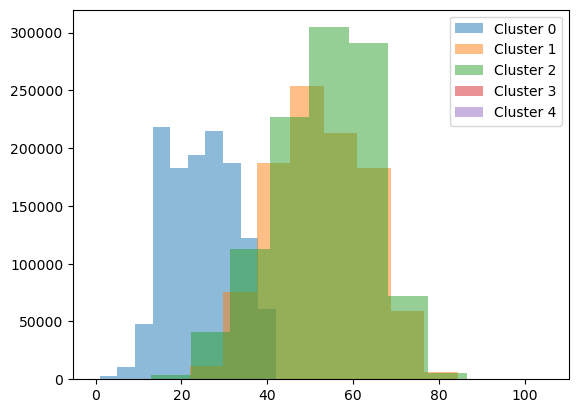

In [58]:
import matplotlib.pyplot as plt

# Crear un histograma por cluster
for i in range(5):
    plt.hist(df_datos.loc[df_datos['Cluster'] == i, 'Edad_desescalada'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()


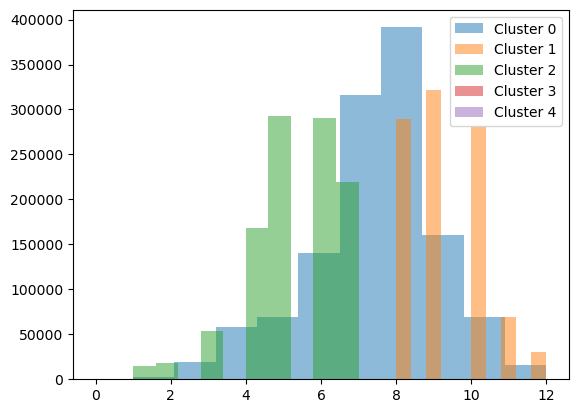

In [61]:
# Crear un histograma por cluster
for i in range(5):
    plt.hist(df_datos.loc[df_datos['Cluster'] == i, 'Mes_desescalada'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()

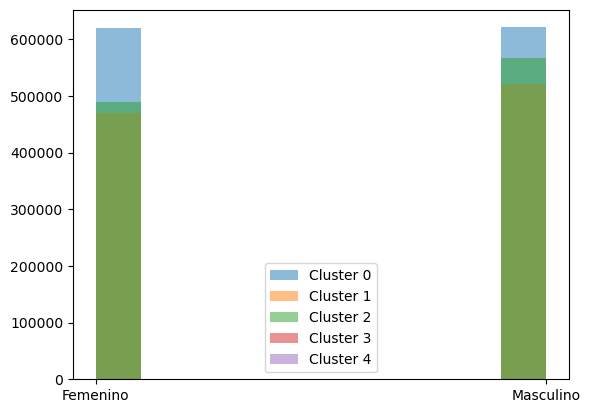

In [67]:
# Crear un histograma por cluster
for i in range(5):
    plt.hist(df_datos.loc[df_datos['Cluster'] == i, 'Sexo'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()

In [ ]:
# Crear un histograma por cluster
for i in range(5):
    plt.hist(df_datos.loc[df_datos['Cluster'] == i, 'P'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()